# LEARNING OBJECTIVE

This notebook shows how Prandtl's boundary layer (BL) equations are derived from the 2D iNS. The equations are solved using a self-similar transformation and numerical methods for the BL flow past a flat plate subject to no pressure gradient (Blasius' problem).

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# ploting customizations
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np
from scipy.integrate import solve_bvp
from scipy.optimize import root_scalar as nsolve

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# PRANDTL'S BOUNDARY LAYER EQUATIONS


Assuming a 2D planar flow $\underline{v} = u(x,y) \underline{\hat{i}} + v(x,y) \underline{\hat{j}}$, we wish to simplify the "full" steady 2D iNS for the situation in which the flow is taking place in a _slender_ geometry with the typical horizontal length scale $L\gg\delta_0$ compared to the typical vertical length scale $\delta_0$. Experiments suggest to us that boundary layers are long and thin, justifying this assumption.

Such a simplification is possible, and physically meaningful (see Panton Sect. 16.4), **in the limit of $Re\to\infty$**, only if $\underline{\delta_0/L = Re^{-1/2}}$ for a Reynolds number $Re = U_0L/\nu$. Then, as $Re\to\infty$, the 2D iNS simplify into Prandtl's boundary layer (BL) equations:
\begin{align*}
  \frac{\partial u^*}{\partial x^*} + \frac{\partial v^*}{\partial y^*} &= 0 &&\quad(\mathrm{COM}),\\
  u^* \frac{\partial u^*}{\partial x^*} + v^* \frac{\partial u^*}{\partial y^*} &= -\frac{\partial p^*}{\partial x^*} + \frac{\partial^2 u^*}{\partial y^{*2}} &&\quad(\mathrm{COLM}-x), \\
  0 &= -\frac{\partial p^*}{\partial y^*} &&\quad(\mathrm{COLM}-y),
\end{align*}
where the starred variables are dimensionless:
\begin{alignat*}{2}
  x^* &= x/L,\;\; & y^* &= y/\delta_0,\\
  u^*(x^*,y^*) &= u(x,y)/U_0,\;\; & v^*(x^*,y^*) &= v(x,y)/(\delta_0 U_0/L),\\
  p^*(x^*,y^*) &= p(x,y)/(\rho U_0^2).
\end{alignat*}

---

Because the pressure in the BL does not vary vertically in a fluid column (this from the COLM-$y$ equation above), then at any $x$ it must be the same as the pressure in the outer ideal flow (the incompressible, irrotational, inviscid flow far above the surface). Then, the COLM equation for ideal flow (which happens to be Bernoulli's equation pointwise) yields
$$ 
    p^*(x) + \frac{1}{2}[u_e^*(x^*)]^2 = \text{constant} 
    \quad\Rightarrow\quad 
    -\frac{\partial p^*}{\partial x^*} = - \frac{dp^*}{dx^*} = u_e^*(x^*) \frac{du_e^*}{dx^*},
$$
where $u_e^*(x^*) = u_e(x)/U_0$ is the given (dimensionless) "external" (to the BL) ideal flow.

---

**Important note:** because we let $y^*=y/\delta_0$ and $\delta_0 = L/\sqrt{Re}$, then $\delta_0 \to 0$ as $Re \to \infty$ (the limit we took to derive Prandtl's equations). So, even though the edge of the BL is at $y=$ (some finite value), this gets mapped to $y^*=$ (some finite value)/(something going to $0$) $\to \infty$. We've "zoomed in" infinitely close to the plate to "see" the BL, and we must "zoom out" to infinity to get out of the BL.

# BLASIUS' PROBLEM


For his PhD dissertation under [L. Prandtl](https://en.wikipedia.org/wiki/Ludwig_Prandtl), [P. R. H. Blasius](https://en.wikipedia.org/wiki/Paul_Richard_Heinrich_Blasius) found a self-similar solution to the BL equations for uniform outer flow, $u_e^*(x^*) = u_e(x)/U_0 = 1$, which means that $du_e^*/dx^*=0$, hence $dp^*/dx^*=0$.

This [solution](https://en.wikipedia.org/wiki/Blasius_boundary_layer) to corresponds to a zero pressure gradient BL created by uniform flow past a flat plate.

## Self-similar transformation and its justification

The idea of finding a solution using self-similar transformation, which we have employed before, can be used to reduce Prandtl's BL equations to a _single_ ODE for certain external (outer) flows. The simplest such case is Blasius' problem with $u_e^* =1$.

If we stare at COLM-$x$ for a moment, it sort of (but not quite) looks like PDE for Stokes' problem because the term $\partial u^*/\partial x^*$ on the LHS looks like $\partial u/\partial t$ with $t$ replaced by $x^*$, and the term $\partial^2 u^*/\partial y^{*2}$ is on the RHS in both problems. Conceptually: time is replaced with distance along the plate. It makes sense, the BL is _not_ fully developed but it is steady; it doesn't "evolve" in time but it "evolves" _along_ the plate!

Thus, we may hypothesize, that just as in Stokes' first problem, a similarity variable $\eta = y^*/\delta(x^*)$ with $\delta(x^*) = \sqrt{x^*}$ may reduce the problem to an ODE. Let's try it.

----

Let $u^*(x^*,y^*) = f'(\eta)$. Why the $'$? We'll see immediately. First,
$$ 
    \frac{\partial u^*}{\partial x^*} = f''(\eta)\frac{\partial \eta}{\partial x^*} = f''(\eta) \left(-\frac{1}{2}\right) \frac{y^*}{x^{*3/2}} .
$$
Second, substitute this into COM:
$$ 
    -\frac{1}{2}f''(\eta)\frac{y^*}{x^{*3/2}} + \frac{\partial v^*}{\partial y^*} = 0 
$$
or
$$ 
    -\frac{1}{2}f''(\eta)\frac{\eta}{x^*} + \frac{\partial v^*}{\partial y^*} = 0 
$$
or
$$ 
    \frac{\partial v^*}{\partial y^*} = \frac{1}{2}f''(\eta)\frac{\eta}{x^*}.
$$
Now what? Well, we need to get rid of $x^*$ and $y^*$ to make the self-similar transformation work, let's try the following:
$$ 
    \frac{\partial (v^* \sqrt{x^*})}{\partial y^*} = \frac{1}{2}f''(\eta)\frac{\eta}{\sqrt{x^*}}. 
$$
Then,
$$ 
    \frac{\partial (v^* \sqrt{x^*})}{\partial \eta}\frac{\partial \eta}{\partial y^*} = \frac{1}{2}f''(\eta)\frac{\eta}{\sqrt{x^*}} 
$$
or
$$ 
    \frac{\partial (v^* \sqrt{x^*})}{\partial \eta}\frac{1}{\sqrt{x^*}}= \frac{1}{2}f''(\eta)\eta\frac{1}{\sqrt{x^*}}
$$
or
$$ 
    \frac{\partial (v^* \sqrt{x^*})}{\partial \eta} = \frac{1}{2}f''(\eta)\eta .
$$

[Eureka!](https://en.wikipedia.org/wiki/Eureka_(word)#Archimedes) The RHS can be integrated _by parts_ with respect to $\eta$:
$$ 
    v^* \sqrt{x^*} = \frac{1}{2} \int f''(\eta)\eta \,d\eta = \frac{1}{2}\left(f'(\eta)\eta - \int f'(\eta)\cdot 1 \,d\eta \right) = \frac{1}{2}\left(f'(\eta)\eta - f(\eta)\right).
$$
Now we see why it was convenient to make $u^*$ the derivative of $f$ with respect to $\eta$; otherwise we wouldn't be able to integrate by parts easily (we'd be left with a $\int f(\eta)\cdot 1\,d\eta = ???$).

(The constant of integration from the indefinite integration $\int f' \,d\eta = f$ is set to zero to ensure no slip at the wall: $v^*|_{y^*=0}=f(0)=0$. More on the boundary conditions below.)

---

Thus, we have proven that the self-similar transformation works, and COM is satisfied (becomes $0=0$, which evaluates to `true`), if we define
$$ 
    u^*(x^*,y^*) = f'(\eta) \quad\mathrm{and}\quad v^*(x^*,y^*) = \frac{1}{2\sqrt{x^*}}\big(\eta f'(\eta) - f(\eta)\big). 
$$

## Reduction to an ODE


The rest is history, as they say... We transform COLM-$x$ using the velocities above, clean up the expression and obtain the _Blasius_ ODE:
$$ f'''(\eta) + \frac{1}{2}f(\eta)f''(\eta) = 0. $$
Unfortunately, it is a nonlinear ODE, and we don't have any tricks to solve it analytically. Suprisingly, a lot can still be deduced about the solution, as [J. P. Boyd elegantly explains](https://epubs.siam.org/doi/pdf/10.1137/070681594).

The boundary conditions of no slip at the wall, and the condition that the horizontal velocity must eventually match the outer free stream ideal flow (see Panton Eqs. (20.1.13)) lead us to 3 boundary condtions (BCs) for the this 3rd-order ODE:
The boundary conditions
\begin{alignat*}{4}
    v^*|_{y^*=0} &= 0& &\quad\Rightarrow\quad& f(0) &= 0,&\\
    u^*|_{y^*=0} &= 0& &\quad\Rightarrow\quad& f'(0) &= 0,&\\
    u^*|_{y^*\to\infty} &\to 1& &\quad\Rightarrow\quad& f'(\infty) &= 1.&
\end{alignat*}
So, it seems that we're in business. The self-similar transformation worked.

## Numerical solution of the Blasius BVP


Now, we solve the nonlinear boundary-value problem (BVP) corresponding to Blasius's problem of the laminar BL due to uniform flow past a flat plate [Panton's Eqs. (20.1.12), (20.1.13)].

A BVP consists of an ODE and its BCs.

First, let $f_0 = f$, $f_1 = f'$ and $f_2 = f''$, then the third-order Blasius ODE can be converted to a first-order system as (see also Panton, pp. 248&ndash;249 and Appendix E):
\begin{align*}
    f_0' &= f' \underbrace{=}_{\text{by def}} f_1,\\
    f_1' &= f'' \underbrace{=}_{\text{by def}} f_2,\\
    f_2' &= f''' \underbrace{=}_{\text{from ODE}} -\frac{1}{2}ff'' \underbrace{=}_{\text{by def}}  -\frac{1}{2}f_0f_2,
\end{align*}
or
$$ 
    \frac{d}{d\eta}\begin{pmatrix} f_0\\ f_1 \\ f_2\end{pmatrix} =  
\begin{pmatrix} f_1\\ f_2 \\ -\frac{1}{2}f_0f_2 \end{pmatrix}.
$$

In [2]:
# python implementation of the right-hand side of the Blasius ODE,
# when written as a first-order system of 3 equations
def ode_fun(eta, f):
  return np.vstack((f[1], f[2], -0.5*f[0]*f[2]))

The BCs above become
\begin{alignat*}{2}
\text{at }\eta = 0 &: \qquad f_0(0) - 0 &= 0,\\
\text{at }\eta = 0 &: \qquad f_1(0) - 0 &= 0,\\
\text{as }\eta \to \infty &: \qquad f_1(\infty) - 1 &\;=0,
\end{alignat*}
for implementation purposes.

In [3]:
# python implementation of the BCs for Blasius' problem
# fa = value of f array at left endpoint, eta = 0
# fb = value of f array at right endpoint, eta = inf
# the number of array entries is the number of BCs, three per above
def bc(fa, fb):
  return np.array([fa[0] - 0, fa[1] - 0, fb[1] - 1])

In [4]:
# specify the value of eta that we shall consider
# to be 'infinity' (for all practical purposes)
inf = 6

# number of grid points we want to have between 0 and inf
ngrid = 50

# create the computational grid
eta = np.linspace(0, inf, ngrid)

# pick a tolerance for the nonlinear BVP solver,
# to ensure the solution is accruate, I've chosen
# a values smaller than the solver's default (1e-3)
mytol = 1e-8

Next, we provide guesses for $f_0,f_1,f_2$ to get the numerical solver started.

Uniform constant values, such as $f_0=0$, $f_1=1$ and $f_2=1$ for all $\eta$, are often OK. **But** if `inf` is too large, these guesses might not be good and we might get a different solution branch of the nonlinear ODE...! (We'll experiment with other guesses below.)

In [5]:
fguess = np.zeros((3, eta.size))
fguess[0] = 0
fguess[1] = 1
fguess[2] = 1

Now, we use [`solve_bvp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_bvp.html) from SciPy to solve Blasius' problem (that is, the BVP derived) numerically, and Matplotlib to visualize the solution.

In [6]:
# you may also try verbose=2 to display progress during iterations
res = solve_bvp(ode_fun, bc, eta, fguess, tol=mytol, verbose=1)
if res.status != 0:
  print("WARNING: res.status is %d" % res.status)
print(res.message)

Solved in 3 iterations, number of nodes 281. 
Maximum relative residual: 9.75e-09 
Maximum boundary residual: 9.32e-25
The algorithm converged to the desired accuracy.


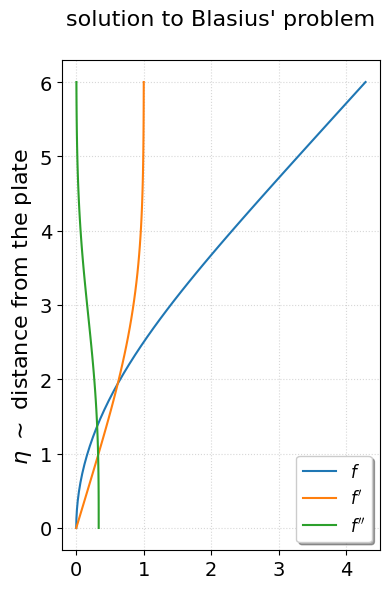

In [7]:
# grab arrays for f, fp = f' and fpp = f''
f_plot = res.sol(eta)[0]
fp_plot = res.sol(eta)[1]
fpp_plot = res.sol(eta)[2]

fig, ax = plt.subplots(tight_layout=True)

ax.plot(f_plot, eta, label="$f$")
ax.plot(fp_plot, eta, label="$f'$")
ax.plot(fpp_plot, eta, label="$f''$")

ax.grid(alpha=0.5, linestyle='dotted')
ax.legend(framealpha=1, shadow=True)

ax.set_ylabel(r"$\eta ~\sim$ distance from the plate")
ax.set_title(r"solution to Blasius' problem")

fig.set_size_inches(4, 6)

Observe that $f'\to1$ and becomes almost constant for large $\eta$. This observation is consistent with $f''\to0$ and $f\sim \eta$ (indeed, $f$ looks linear for large $\eta$ from the plot).

## Discussion

### Boundary layer thickness

To determine the BL's thickness, we can find where the (dimensionless) horizontal velocity becomes 99% of the (dimensionless) free stream velocity of 1. That is, we need to find $\eta_{99\%}$ such that $f'(\eta_{99\%}) = 0.99$. To do so, we use a SciPy [nonlinear solver](https://docs.scipy.org/doc/scipy/reference/optimize.html).

In [8]:
def fp99eq(eta):
  return res.sol(eta)[1] - 0.99

# use scipy.optimize rootfinder to solve f' - 0.99 = 0
# with initial guess ('x0') of eta* = 1
sol = nsolve(fp99eq, x0=1, rtol=mytol)
eta99 = sol.root
print(" solution of f'(eta) = 0.99 is eta_99% =", eta99)

 solution of f'(eta) = 0.99 is eta_99% = 4.854910820260161


Let's visualize it.

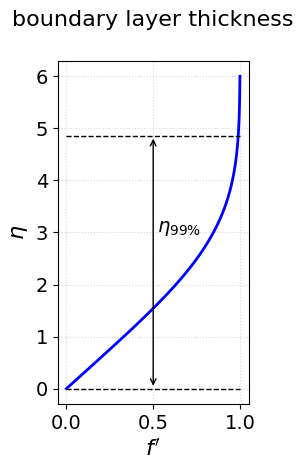

In [9]:
fig, ax = plt.subplots(tight_layout=True)

ax.plot(fp_plot, eta, color='blue', linewidth='2') 

ax.set_xlabel(r"$f'$")
ax.set_ylabel(r"$\eta$")

ax.grid(alpha=0.5, linestyle='dotted')

x11 = np.linspace(0, 1, num=11)
ax.plot(x11, eta99*np.ones_like(x11), color='black', linewidth=1, linestyle='dashed')
ax.plot(x11, 0*np.ones_like(x11), color='black', linewidth=1, linestyle='dashed')

# add nice arrows
ax.text(0.52, 3, r"$\eta_{99\%}$", fontdict={'size': 14})
        #bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.annotate("", (0.5, 0), (0.5, eta99), arrowprops={'arrowstyle':'<->'})

ax.set_title('boundary layer thickness')
ax.set_aspect(0.3, 'box')

### Wall shear stress (and the friction coefficient)

The nontrivial component of shear stress in this 2D flow is
$$
  \tau_{xy} = \mu \bigg( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \bigg).
$$
In terms of the dimensionless variables introduced above:
\begin{align*}
  \tau_{xy} &= \mu\bigg( \frac{U_0}{\delta_0}\frac{\partial u^*}{\partial y^*} + \frac{\overbrace{U_0\delta_0/L}^{=V_0}}{L}\frac{\partial v^*}{\partial x^*} \bigg) \\
  &= \frac{\mu U_0}{\delta_0}\left(\frac{\partial u^*}{\partial y^*} + \frac{\delta_0^2}{L^2}\frac{\partial v^*}{\partial x^*} \right)\\
  &= \frac{\mu U_0}{\delta_0} \bigg( \frac{\partial u^*}{\partial y^*} + \underbrace{\frac{1}{Re}\frac{\partial v^*}{\partial x^*}}_{\to 0\text{ as }Re\to\infty} \bigg)\\
\end{align*}
So, actually, in the limit of BL theory, the shear stress is entirely determined by ${\partial u^*}/{\partial y^*}$
Although, for reference, after a lengthy calculation from the definitions, we have
\begin{align*}
  \frac{\partial v^*}{\partial x^*} &= \frac{1}{4(x^*)^{3/2}}\left[ f(\eta) - \eta f'(\eta) - \eta^2 f''(\eta) \right],\\
  \frac{\partial u^*}{\partial y^*} &= \frac{1}{\sqrt{x^*}}f''(\eta).
\end{align*}

The wall shear stress is $\tau_{xy}$ at $y=0$ $\Rightarrow y^*=0$ or $\eta=0$. Together with the BC $f(0)=0$, this means that ${\partial v^*}/{\partial x^*} \to 0$ as $\eta\to0$. Thus,
$$
  \tau_{\mathrm{wall}} 
  = \frac{\mu U_0}{\delta_0} \left.\frac{\partial u^*}{\partial y^*}\right|_{y^*=0} 
  =  \frac{\mu U_0}{\delta_0} \frac{1}{\sqrt{x^*}} f''(0),
$$
which can be rewritten as
$$
  \tau_{\mathrm{wall}} 
  = \frac{\mu U_0 \sqrt{U_0 L}}{L \sqrt{\nu}} \frac{1}{\sqrt{x/L}} f''(0) 
  = \frac{\rho \nu U_0^2 \sqrt{L^2}}{L \sqrt{U_0\nu}} \frac{1}{\sqrt{x}} f''(0) 
  = \rho U_0^2 \sqrt{\frac{\nu}{U_0x}} f''(0).
$$
This expression leads to introduce the _local_ Reynolds number
$$
  Re_x = \frac{U_0 x}{\nu}.
$$

As Panton discusses on p. 537, it is then conventional to introduce  know the _friction coefficient_ $C_f$ as a dimensionless wall shear stress:
$$
  C_f(x) = \frac{\tau_{\mathrm{wall}}}{\tfrac{1}{2}\rho U_0^2} = 2Re_x^{-1/2}f''(0).
$$

Thus, we care about the numerical value of $f''(0)$, from which one calculates $C_f(x)$, and eventually $\tau_{\mathrm{wall}}(x)$.

In [10]:
fpp0 = res.sol(eta)[2][0]
print(f"f''(0) = {fpp0:.10f}")

f''(0) = 0.3325659312


### What are the meaningful quantities to plot?

To gain a physical understanding of the solution to the BVP, we plot it slightly differently. In particular, we care about
\begin{alignat*}{4}
  u^* &= f'(\eta)& &\quad\Rightarrow\quad& u(x,y) &= U_0f'(\eta),& \\
  v^* &= \tfrac{1}{2\sqrt{x^*}}\big(\eta f'(\eta) - f(\eta)\big)& &\quad\Rightarrow\quad&  v(x,y) &= U_0 Re_x^{-1/2}\tfrac{1}{2}\big(\eta f'(\eta) - f(\eta)\big),&\\
  \tau^* &= \frac{1}{\sqrt{x^*}} f''(\eta)& &\quad\Rightarrow\quad& \tau_{xy}(x,y) &= \rho U_0^2 Re_x^{-1/2} f''(\eta).&
\end{alignat*}
and


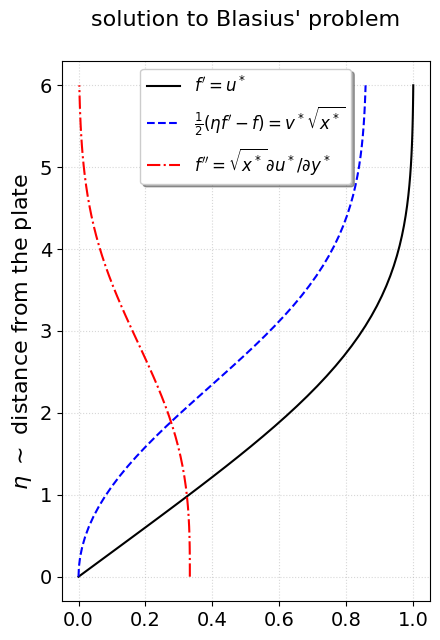

In [11]:
fig, ax = plt.subplots(tight_layout=True)

ax.plot(fp_plot, eta, label="$f'= u^*$",
        linestyle='-', color='k')
ax.plot(0.5*(eta*fp_plot - f_plot), eta,
        linestyle='--', color='b',
        label=r"$\frac{1}{2}(\eta f' - f) = v^*\sqrt{x^*}$")
ax.plot(fpp_plot, eta,
        linestyle='-.', color='r',
        label=r"$f''=\sqrt{x^*}\partial u^*/\partial y^*$")

ax.grid(alpha=0.5, linestyle='dotted')
ax.legend(framealpha=1, shadow=True)

ax.set_ylabel(r"$\eta ~\sim$ distance from the plate")
ax.set_title("solution to Blasius' problem")

fig.set_size_inches(4.5, 6.5)

In [ ]:
#fig.savefig("blasius.pdf",bbox_inches='tight')

Compare the black curve above to the experimental profile from [Van Dyke's _Album of Fluid Motion_](https://drive.google.com/file/d/0B5UvitjuXx-bVWdoMFQxUXlZek0/view?resourcekey=0-6l7d0NYe7FY8muhx8pCL8A):

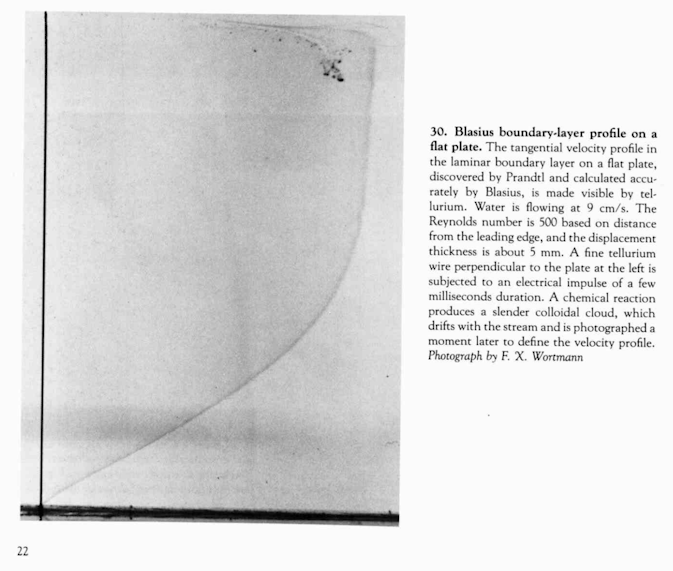

### The self-similarity concept


Let's undo the transformation from $f$ and $\eta$ back to $u^*(x^*,y^*)$ and $v^*(x^*,y^*)$ to plot the spatially _developing_ BL and velocity profile from its universal shape.

We evaluate the velocities from the numerical solution to the Blasius ODE. And return to dimensional variables:
\begin{align*}
    u(x,y) &= U_0f'(\eta), \\
    v(x,y) &= U_0 Re_x^{-1/2}\tfrac{1}{2}\big(\eta f'(\eta) - f(\eta)\big), \\
    \tau_w &= \tau_{xy}(x,y=0) = \rho U_0^2 Re_x^{-1/2} f''(0).
\end{align*}


**Important note:** the thickness $\delta(x^*) = \sqrt{x^*}$ is dimensionless at this point, the dimensional one is 
$$
  \delta(x) = \delta_0 \sqrt{x^*} = L Re^{-1/2} \sqrt{x/L} =  x Re_x^{-1/2},
$$
which is needed to evaluate $\eta = y^*/\delta(x^*) = y/\delta(x) = y/\big(x Re_x^{-1/2}\big)$.

In [13]:
# kinematic viscosity of water
nu = 1e-6 # m^2/s, so time will be in s and distance in m for the plots below
rho = 1000 # kg/m^3

In [14]:
def uBL(x,y,U0):
  Rex = U0*x/nu
  myeta = y/(x/np.sqrt(Rex))
  return U0*res.sol(myeta)[1]

def vBL(x,y,U0):
  Rex = U0*x/nu
  myeta = y/(x/np.sqrt(Rex))
  return U0/np.sqrt(Rex)*0.5*(myeta*res.sol(myeta)[1] - res.sol(myeta)[0])

def tauw(x,U0):
  Rex = U0*x/nu
  return rho*U0**2/np.sqrt(Rex)*res.sol(0)[2]

In [15]:
def plot_BL_dimensional(U0):
    x0 = 2 # don't start at 0 because things blowup
    xmax = 5*x0
    ymax = 15 # picked to look nice
    x, y = np.meshgrid( np.linspace(x0, xmax, num=8),
                        np.linspace(0, ymax, num=25) )
    qs = 10 # scaling factor for quiver plot

    fig, ax = plt.subplots(tight_layout=True)

    ax.set_xlabel('$x$ [m]')
    ax.set_ylabel('$y$ [mm]')
    ax.set_ylim(0, ymax)

    ax.grid(alpha=0.5, linestyle='dotted')

    # plot the edge of the BL, the 99% thickness
    xx = np.linspace(x0, xmax, num=100)
    delta99 = eta99*(x/np.sqrt(U0*x/nu))
    lh1, = ax.plot(x[0,:], delta99[0,:]*1e3, color='goldenrod', linewidth=3, label='')

    # plot the velocity field arrows,
    # but only close to the BL, for clarity
    xq = x[y < 1.5*delta99*1e3]
    yq = y[y < 1.5*delta99*1e3]
    qv = ax.quiver(xq, yq, uBL(xq,yq/1e3,U0), vBL(xq,yq/1e3,U0),
                   scale=qs, scale_units='x', color='blue')
    ax.quiverkey(qv, 3, 0.9*ymax, U0, coordinates='data',
                 label=f'$U_0={U0:.0f}$ m/s', labelpos='E',
                 fontproperties={'size':14})
    
    ax.text(2.5, 0.8*ymax, f'$Re_L = {np.sqrt(U0*xmax/nu):.2f}$', fontdict={'size':14})

    # plot the slope at the wall -- tau_w, the wall shear stress
    for xxq in xq:
        # xxq has many repeating values, so stop once xmax is reached
        if xxq == xmax:
            break
        # delete points above some y distance from plot for clarity
        yms = delta99[0,0]*1e3/2
        yy = np.fmin((xx-xxq)/tauw(xxq,U0)*qs,yms)
        yy[yy >= yms] = np.nan
        # plot the slope
        lh2, = ax.plot(xx, yy, color='red', linestyle='-.', label='')

    # customize legend to show only delta, and *one* tau_w
    ax.legend([lh1,lh2],[r'$\delta_{99\%} (x)$',r'$\tau_w(x)$'])
    
    plt.show()

In [ ]:
interact(plot_BL_dimensional, U0 = widgets.FloatSlider(value=4,
                                                       min=1,
                                                       max=10,
                                                       step=0.5));

interactive(children=(FloatSlider(value=4.0, description='U0', max=10.0, min=1.0, step=0.5), Output()), _dom_c…

The <font color="red">red</font> curve in the plot is the _dimensional_ 99% BL thickness, denoted $\delta_{99\%}(x)$. This thickness is defined as $\eta = \eta_{99\%}$ where $u^* = f'(\eta_{99\%}) = 0.99$. From the defintion $\eta = y^*/\delta(x^*)$, we have
$$
  y^* = \eta_{99\%} \delta^*(x^*) = \eta_{99\%} \sqrt{x^*} \approx 4.9 \sqrt{x^*} = \delta_{99\%}^*(x^*).
$$
In dimensional form,
$$
  \delta_{99\%}(x) = \delta_0\eta_{99\%} \sqrt{x/L} = L Re^{-1/2} \eta_{99\%} \sqrt{x/L} = \eta_{99\%} x Re_x^{-1/2}
$$ 
or 
$$
  \delta_{99\%}(x)/x = \eta_{99\%} Re_x^{-1/2}
$$
as is traditional to write it.

**Note**: we plot the velocity field away from the leading edge $x=0$ because Prandtl's BL equations are not valid there. Indeed, if you plot the $u$ and $v$ closer to $x=0$, you will see they don't make sense.

## Verification

How do we know the above numerical solution is correct? It looks OK, but _how can we be sure_?

To answer this question, we can perform some basic _verification_, which means checking the self-consistency of the numerical approach. (_Validation_ would require comparison against experimental data or other theory; see, for example, Panton's Fig. 20.2.)

Verification of the numerical solution requires
1.   checking that the solution looks the same (more formally, "has converged") the same if `inf` is increased
2.   checking that the solution looks the same (more formally, "has converged") if `ngrid` is increased,

We must pick some quantities to compare across grids. We pick $f''(0)$ and $\eta_{99\%}$ (such that $f'(\eta_{99\%})=0.99$); $f''(0)$ is relevant because it sets the wall shear stress, $\eta_{99\%}$ is relvant because it sets the BL thickness. We would like to get both of these quantitatively correct.

(We also know to expect $f''(0)\approx 0.33206$ and $\eta_{99\%} = 4.9$ (see Panton p. 536), which can serve as a _validation_.)

### 1. `inf`

Now, we can check if our choice of "fake" infinity was good by solving the BvP numerically on larger domains up to `2.5*inf`, and seeing if $f''(0)$ is converging to several decimals. (I picked 2.5 for illustration, you can go bigger if you wish.)

One tricky aspect is that as the "fake" infinity becomes larger, our initial constant guesses become bad. So, we update our initial solver guess based on our intution from the earlier plots.

In [17]:
for infnew in np.arange(inf,2.5*inf):
  # update eta vector
  etanew = np.linspace(0,infnew,ngrid)
  # update initial guesses on new domain
  # use guess motivated by the earlier observations
  fguess = np.zeros((3, etanew.size))
  fguess[0] = 1
  fguess[1] = etanew
  fguess[2] = 0

  # re-solve the BVP
  res = solve_bvp(ode_fun, bc, etanew, fguess, tol=mytol, verbose=1)
  if res.status != 0:
    print("WARNING: res.status is %d" % res.status)
  print(res.message)

  fpp0 = res.sol(etanew)[2][0]

  # the next line works because we've overwritten the global res
  # variable, which stores the solution and is used to define fp99eq
  sol = nsolve(fp99eq, x0=1, rtol=mytol)
  eta99 = sol.root

  print(f"With inf = {infnew:.2f}, f\''(0) = {fpp0:.10f} and eta_99% = {eta99:.10f}.\n\n")

Solved in 4 iterations, number of nodes 308. 
Maximum relative residual: 9.96e-09 
Maximum boundary residual: 1.51e-26
The algorithm converged to the desired accuracy.
With inf = 6.00, f''(0) = 0.3325659312 and eta_99% = 4.8549108167.


Solved in 4 iterations, number of nodes 284. 
Maximum relative residual: 9.85e-09 
Maximum boundary residual: 4.57e-25
The algorithm converged to the desired accuracy.
With inf = 7.00, f''(0) = 0.3320963579 and eta_99% = 4.9055973208.


Solved in 4 iterations, number of nodes 306. 
Maximum relative residual: 9.96e-09 
Maximum boundary residual: 6.41e-28
The algorithm converged to the desired accuracy.
With inf = 8.00, f''(0) = 0.3320591918 and eta_99% = 4.9097799919.


Solved in 4 iterations, number of nodes 367. 
Maximum relative residual: 9.92e-09 
Maximum boundary residual: 2.88e-26
The algorithm converged to the desired accuracy.
With inf = 9.00, f''(0) = 0.3320573908 and eta_99% = 4.9099833475.


Solved in 4 iterations, number of nodes 361. 
Maximu

The relative residuals tell us, roughly, what the error in the computed quantities is, and how many of the digits we can trust. They are low, and the computed values appear to be well converged for `eta = 10` and larger.

Further, if a digit of $f''(0)$ or $\eta_{99\%}$ does not change between choises of `inf`, then that digit is considered "converged" (you can trust it).

**Important note:** from this analysis, and the $f''(0)$ values, we see that our first solution, which we plotted above, wasn't the most accurate one!

### 2. `ngrid`

We can check if our choice of grid was sufficiently fine by solving the BVP numerically on finer domains up to `3*ngrid`, and seeing if $f''(0)$ is converging to several decimals.

(Note, however, that `ngrid = 50` is really only the _initial_ grid. SciPy's `solve_bvp` updates the grid if it feels that it's insufficiently fine, and you see this in the solver ouput below.)

In [18]:
# this test will start the largest infnew from the previous step,
# but we will change ngrid

for ngridnew in [ngrid, 2*ngrid, 3*ngrid]:
  # update eta vector
  etanew = np.linspace(0,infnew,ngridnew)
  # update initial guesses on new domain
  # use guess motivated by the earlier observations
  fguess = np.zeros((3, etanew.size))
  fguess[0] = 1
  fguess[1] = etanew
  fguess[2] = 0

  # re-solve the BVP
  res = solve_bvp(ode_fun, bc, etanew, fguess, tol=mytol, verbose=1)
  if res.status != 0:
    print("WARNING: res.status is %d" % res.status)
  print(res.message)

  fpp0 = res.sol(etanew)[2][0]

  # the next line works because we've over-written the global res
  # variable, which stores the solution and is used to define fp99eq
  sol = nsolve(fp99eq, x0=1, rtol=mytol)
  eta99 = sol.root

  print(f"With inf = {infnew:.2f}, f\''(0) = {fpp0:.10f} and eta_99% = {eta99:.10f}.\n\n")

Solved in 4 iterations, number of nodes 326. 
Maximum relative residual: 9.83e-09 
Maximum boundary residual: 8.83e-26
The algorithm converged to the desired accuracy.
With inf = 14.00, f''(0) = 0.3320573362 and eta_99% = 4.9099895127.


Solved in 4 iterations, number of nodes 347. 
Maximum relative residual: 9.80e-09 
Maximum boundary residual: 3.04e-26
The algorithm converged to the desired accuracy.
With inf = 14.00, f''(0) = 0.3320573362 and eta_99% = 4.9099895126.


Solved in 3 iterations, number of nodes 367. 
Maximum relative residual: 9.91e-09 
Maximum boundary residual: 1.03e-24
The algorithm converged to the desired accuracy.
With inf = 14.00, f''(0) = 0.3320573362 and eta_99% = 4.9099895132.




The solver converges in fewer iterations for finer starting grids. However, it seems that `ngrid = 50` was "good enough" to start with because the solution is almost the same for all cases.